In [13]:
from src.utils.config import popularity, load_env_file
from src.utils.files import read_file

from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_log_error
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.utils import resample
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.base import clone

import pandas as pd
import numpy as np
import optuna
import math
import warnings
import xgboost as xgb

from umap import UMAP

import plotly.graph_objects as go
from plotly.subplots import make_subplots

import matplotlib.pyplot as plt

import pprint
import optuna.visualization as vis

In [2]:
load_env_file()
df = read_file(popularity, minio={"minio_write": False, "minio_read": False})

.env cargado con exito


In [3]:
def get_metrics(y_test, y_pred):
    '''
    Dados el output predecido del modelo y los datos reales, se construyen
    las métricas necesarias para medir el rendimiento de un modelo de REGRESIÓN.
    '''
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f'MAE (Error Absoluto Medio): {mae:.4f}')
    print(f'RMSE (Raíz del Error Cuadrático Medio): {rmse:.4f}')
    print(f'R2 Score (Coef. de Determinación): {r2:.4f}')

    return {'mae': mae, 'rmse': rmse, 'r2': r2}

In [4]:
def _preprocess(df, image_col='v_clip', use_images=True):
    images_cols = ['v_clip', 'v_convnext', 'v_resnet']

    assert image_col in images_cols, "Seleccione una columna de imágenes válida"

    df_clean = df.copy()
    
    # Encuentra todas las columnas que tengan "video_statistics" en su nombre
    video_cols = [col for col in df_clean.columns if 'video_statistics' in col]

    # Seleccionamos las variables de entrada útiles
    target_col = df_clean['recomendaciones_totales']
    erase_columns = ['id', 'name', 'price_range']
    erase_columns.extend(video_cols)
    images_cols.remove(image_col)
    erase_columns.extend(images_cols)
    df_clean = df_clean.drop(columns=erase_columns, errors='ignore')

    if use_images:
        # Vamos a preparar el DataFrame para que scikit-learn haga el PCA mas adelante
        # Forzamos a que todos los valores de la columna de los embeddings sean iterables
        zero_vector = np.zeros(512)
        df_clean[image_col] = df_clean[image_col].apply(
            lambda x: x if isinstance(x, (list, np.ndarray)) else zero_vector
        )
        
        img_df = pd.DataFrame(df_clean[image_col].tolist(), index=df_clean.index)
        img_df.columns = [f'{image_col}_{i}' for i in range(img_df.shape[1])]
        df_clean = pd.concat([df_clean.drop(columns=[image_col]), img_df], axis=1)
    else:
        # Ya la columna de los embeddings originales no es necesaria
        df_clean = df_clean.drop(columns=[image_col], errors='ignore')

    obj_cols = df_clean.select_dtypes(include=['object', 'str']).columns
    for col in obj_cols:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

    # Solo nos quedamos con columnas numéricas y rellenamos nulos
    df_clean = df_clean.select_dtypes(include=[np.number])
    df_clean = df_clean.fillna(0)

    df_clean['recomendaciones_totales'] = target_col

    return df_clean

Vamos a analizar las variables para saber que transformaciones se deben hacer con ellas

In [5]:
target_name = 'recomendaciones_totales' 
df_analisis_variables = _preprocess(df, image_col='v_clip', use_images=False)

X_analisis = df_analisis_variables.drop(columns=[target_name])
y_analisis = df_analisis_variables[target_name]

print("ASIMETRÍA DE LA VARIABLE RESPUESTA")
print("-" * 40)
sesgo = y_analisis.skew()
problematicas = sesgo[abs(sesgo) > 1]

if len(problematicas) > 0:
    print("La variable respuesta está muy sesgada (valor > 1 o < -1):")
    print(problematicas)
else:
    print("La variable respuesta no presenta un sesgo grave.")

print("\nASIMETRÍA DE LAS VARIABLES REGRESORAS")
print("-" * 40)
sesgo = X_analisis.skew().sort_values(ascending=False)
problematicas = sesgo[abs(sesgo) > 1]

if len(problematicas) > 0:
    print("Las siguientes variables están muy sesgadas (valor > 1 o < -1):")
    print(problematicas)
else:
    print("Ninguna variable presenta un sesgo grave.")

print("\nHISTOGRAMAS DE LAS VARIABLES")
print("-" * 40)

# Calcular la cuadrícula para los subplots
columnas = df_analisis_variables.columns.tolist()
n_cols = 4
n_rows = math.ceil(len(columnas) / n_cols)

# Crear la figura de subplots de Plotly
fig = make_subplots(
    rows=n_rows, 
    cols=n_cols, 
    subplot_titles=columnas,
    vertical_spacing=0.05,
    horizontal_spacing=0.05
)

# Añadir un histograma por cada columna de X
for i, col in enumerate(columnas):
    row = (i // n_cols) + 1
    col_pos = (i % n_cols) + 1
    
    fig.add_trace(
        go.Histogram(
            x=df_analisis_variables[col], 
            name=col, 
            marker=dict(color='#4CAF50', line=dict(color='black', width=1))
        ),
        row=row, 
        col=col_pos
    )

# Ajustar el diseño del gráfico general
fig.update_layout(
    title_text="Distribución de las variables de entrada (X)",
    title_x=0.5,
    title_font_size=20,
    height=300 * n_rows,  # Altura dinámica dependiendo del número de variables
    showlegend=False,
    plot_bgcolor='white'
)

# Mostrar el gráfico interactivo
fig.show()

ASIMETRÍA DE LA VARIABLE RESPUESTA
----------------------------------------
La variable respuesta está muy sesgada (valor > 1 o < -1):
[39.84869786]

ASIMETRÍA DE LAS VARIABLES REGRESORAS
----------------------------------------
Las siguientes variables están muy sesgadas (valor > 1 o < -1):
price_overview                  9.026156
num_languages                   5.806029
total_games_by_publisher        5.785603
total_games_by_developer        5.469786
Online Co-op                    3.652072
Playable without Timed Input    3.540597
Custom Volume Controls          3.507331
Shared/Split Screen             3.405454
Remote Play Together            3.284144
Online PvP                      3.136736
Steam Leaderboards              3.013367
Early Access                    2.771263
Co-op                           2.673924
Steam Trading Cards             2.545976
PvP                             2.466048
Free To Play                    2.445396
Partial Controller Support      2.321911
Multi-play

Como k-nn sufre mucho al tener muchas dimensiones, vamos a analizar cuales son las más importantes con un modelo de XGBoost

In [ ]:
# Silenciar específicamente los avisos para que la salida sea limpia
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_xgb(trial, X_t, y_t, image_col, use_images):
    '''
    Función objetivo a optimizar por Optuna para XGBoost
    '''
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = xgb.XGBRegressor(**params)
    
    steps = []
    
    img_cols = [c for c in X_t.columns if c.startswith(f'{image_col}_')] if use_images else []
    tabular_cols = [c for c in X_t.columns if c not in img_cols]
    
    transformers_list = [
        ('tabular', 'passthrough', tabular_cols)
    ]
    
    if use_images:
        dim_reduction = trial.suggest_categorical('dim_reduction', ['pca', 'umap'])
        
        if dim_reduction == 'pca':
            reducer = PCA(n_components=10, random_state=42)
        else:
            n_neighbors = trial.suggest_int('umap_n_neighbors', 5, 50)
            min_dist = trial.suggest_float('umap_min_dist', 0.0, 0.5)
            reducer = UMAP(n_components=10, n_neighbors=n_neighbors, min_dist=min_dist, random_state=42)
            
        transformers_list.append(('reducer', reducer, img_cols))
        
    preprocessor = ColumnTransformer(transformers=transformers_list, remainder='drop')
    steps.append(('prep', preprocessor))
    steps.append(('xgb', model))
    
    pipeline = Pipeline(steps)
    
    # Transformación de la variable respuesta
    final_model = TransformedTargetRegressor(
        regressor=pipeline,
        func=np.log1p,
        inverse_func=np.expm1
    )
    
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_validate(final_model, X_t, y_t, cv=cv, scoring='neg_mean_absolute_error', return_train_score=True,
                            n_jobs=-1)
    
    trial.set_user_attr("train_mae", -scores['train_score'].mean())
    
    return -scores['test_score'].mean()

combinations = [['v_clip', True]]

results = []
diccionario_importancias = {}

for c in combinations:
    print(f"\n{'='*50}")
    print(f"Evaluando combinación: {c}")
    
    df_prepared = _preprocess(df, image_col=c[0], use_images=c[1])

    X = df_prepared.drop(columns=['recomendaciones_totales'])
    y = df_prepared['recomendaciones_totales']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    study = optuna.create_study(direction='minimize')
    study.optimize(lambda trial: objective_xgb(trial, X_train, y_train, c[0], c[1]), n_trials=35)

    print(f"Mejor MAE Validación: {study.best_value:.4f} | MAE Train: {study.best_trial.user_attrs['train_mae']:.4f}")
    
    best_params = study.best_params
    
    if c[1]:
        tecnica_ganadora = best_params.get('dim_reduction')
        print(f"\n---> INFO PARA EL KNN <---")
        print(f"Técnica de reducción de imágenes ganadora: {tecnica_ganadora.upper()}")
        
        if tecnica_ganadora == 'umap':
            print(f"n_neighbors óptimo para UMAP: {best_params.get('umap_n_neighbors')}")
            print(f"min_dist óptimo para UMAP: {best_params.get('umap_min_dist')}")

    xgb_params = {k: v for k, v in best_params.items() if k not in ['dim_reduction', 'umap_n_neighbors', 'umap_min_dist']}
    best_xgb = xgb.XGBRegressor(**xgb_params, random_state=42, n_jobs=-1)
    
    cols_sesgadas = ['price_overview', 'num_languages', 'total_games_by_publisher', 'total_games_by_developer']
    img_cols = [col for col in X_train.columns if col.startswith(f"{c[0]}_")] if c[1] else []
    cols_binarias = [col for col in X_train.columns if set(X_train[col].dropna().unique()).issubset({0, 1, 0.0, 1.0})]
    cols_normales = [col for col in X_train.columns if col not in cols_sesgadas + img_cols + cols_binarias]
    
    final_transformers = [
        ('sesgadas', PowerTransformer(method='yeo-johnson'), cols_sesgadas),
        ('normales', StandardScaler(), cols_normales),
        ('binarias', 'passthrough', cols_binarias)
    ]
    
    if c[1]:
        dim_reduction = best_params.get('dim_reduction', 'pca')
        if dim_reduction == 'pca':
            final_reducer = PCA(n_components=10, random_state=42)
        else:
            final_reducer = UMAP(n_components=10, n_neighbors=best_params['umap_n_neighbors'], min_dist=best_params['umap_min_dist'], random_state=42)
        final_transformers.append(('reducer', final_reducer, img_cols))
        
    final_preprocessor = ColumnTransformer(transformers=final_transformers, remainder='drop')
    final_pipeline = Pipeline([('prep', final_preprocessor), ('xgb', best_xgb)])
    final_model = TransformedTargetRegressor(regressor=final_pipeline, func=np.log1p, inverse_func=np.expm1)
    
    final_model.fit(X_train, y_train)
    final_preds = final_model.predict(X_test)
    
    metricas = get_metrics(y_test, final_preds)
    
    results.append({
        'image_col': c[0], 
        'use_images': c[1], 
        'val_mae': study.best_value,
        'train_mae': study.best_trial.user_attrs['train_mae'], 
        'test_mae': metricas['mae'],
        'test_rmse': metricas['rmse'],
        'test_r2': metricas['r2']
    })

    modelo_entrenado = final_model.regressor_['xgb']
    # Obtenemos los pesos de cada variable
    pesos = modelo_entrenado.feature_importances_
    
    # Creamos nuestra propia lista de nombres en el mismo orden
    # en el que metimos las variables en el ColumnTransformer
    mis_nombres = cols_sesgadas + cols_normales + cols_binarias
    
    # Si usamos PCA o UMAP, añadimos 10 nombres extra
    if c[1] == True:
        mis_nombres = mis_nombres + [f"img_reducida_{i}" for i in range(10)]

    df_importancias = pd.DataFrame({
        'Variable': mis_nombres,
        'Importancia': pesos
    })
    
    print("\nTOP 10 Variables más importantes")
    display(df_importancias.sort_values(by='Importancia', ascending=False).head(10))

# Imprimimos el resumen de resultados final
df_results = pd.DataFrame(results).sort_values('test_mae', ascending=True)
print("\nRESUMEN FINAL DE RESULTADOS:")
display(df_results)

In [ ]:
display(df_importancias.sort_values(by='Importancia', ascending=False).head(20).reset_index(drop=True))

Observamos que las variables mas significativas son: 
1. Family Sharing
2. Free To Play
3. yt_score
4. Steam Trading Cards
5. price_overview
6. Steam Cloud
7. num_languages
8. Steam Achievements
9. RPG
10. Online Co-op
11. Casual
12. img_reducida_0
13. Custom Volume Controls
14. Simulation
15. release_year
16. Co-op
17. Multi-player
18. Shared/Split Screen
19. Playable without Timed Input
20. total_games_by_publisher


In [ ]:


warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

df_prepared = _preprocess(df, use_images=True)

img_cols = [c for c in df_prepared.columns if c.startswith('v_clip_')]
if img_cols:
    pca = PCA(n_components=10, random_state=42)
    reducidas = pca.fit_transform(df_prepared[img_cols])
    for i in range(10):
        df_prepared[f'img_reducida_{i}'] = reducidas[:, i]
    df_prepared = df_prepared.drop(columns=img_cols)

top_variables = [
    'Family Sharing', 'Free To Play', 'yt_score', 'Steam Trading Cards', 
    'price_overview', 'Steam Cloud', 'num_languages', 'Steam Achievements', 
    'RPG', 'Online Co-op', 'Casual', 'img_reducida_0', 'Custom Volume Controls', 
    'Simulation', 'release_year', 'Co-op', 'Multi-player', 'Shared/Split Screen', 
    'Playable without Timed Input', 'total_games_by_publisher'
]

X = df_prepared[top_variables]
y = df_prepared['recomendaciones_totales']

# AÑADIDO 1: Estratificación
bins_strat = [-1, 10, 100, 1000, 10000, float('inf')]
y_binned = pd.cut(y, bins=bins_strat, labels=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y_binned
)

def objective(trial, X_t, y_t):
    variables_elegidas = []
    for col in top_variables:
        if trial.suggest_categorical(f'usar_{col}', [True, False]):
            variables_elegidas.append(col)
            
    if len(variables_elegidas) == 0:
        return float('inf')
        
    X_filtrada = X_t[variables_elegidas]
    
    n_neighbors = trial.suggest_int('n_neighbors', 3, 50)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    p = trial.suggest_int('p', 1, 2)
    
    modelo_knn = KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights, p=p, n_jobs=-1)
    
    todas_sesgadas = ['num_languages', 'price_overview', 'total_games_by_publisher']
    todas_normales = ['yt_score', 'release_year', 'img_reducida_0']
    
    cols_sesgadas = [c for c in variables_elegidas if c in todas_sesgadas]
    cols_normales = [c for c in variables_elegidas if c in todas_normales]
    cols_binarias = [c for c in variables_elegidas if c not in cols_sesgadas + cols_normales]
    
    transformers_list = [
        ('sesgadas', PowerTransformer(method='yeo-johnson'), cols_sesgadas),
        ('normales', StandardScaler(), cols_normales),
        ('binarias', 'passthrough', cols_binarias)
    ]
    
    preprocessor = ColumnTransformer(transformers=transformers_list, remainder='drop')
    pipeline = Pipeline([('prep', preprocessor), ('knn', modelo_knn)])
    final_model = TransformedTargetRegressor(regressor=pipeline, func=np.log1p, inverse_func=np.expm1)
    
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_validate(final_model, X_filtrada, y_t, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
    
    return -scores['test_score'].mean()

print("Buscando las mejores variables e hiperparámetros...")
study = optuna.create_study(direction='minimize')
study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=300)

print(f"\nMejor MAE en Validación: {study.best_value:.4f}")

# AÑADIDO 2: Visualización de importancias
importancias = optuna.importance.get_param_importances(study)
df_importancias = pd.DataFrame(list(importancias.items()), columns=['Parámetro', 'Importancia (%)'])
df_importancias['Importancia (%)'] = (df_importancias['Importancia (%)'] * 100).round(2)

print("\n---> TOP PARÁMETROS Y VARIABLES MÁS INFLUYENTES <---")
display(df_importancias.head(15))

try:
    display(vis.plot_param_importances(study))
except:
    pass


mejores_parametros = study.best_params
variables_ganadoras = [col for col in top_variables if mejores_parametros[f'usar_{col}'] == True]

print(f"\nOptuna ha decidido usar solo estas {len(variables_ganadoras)} variables:")
for v in variables_ganadoras:
    print(f" - {v}")

X_train_final = X_train[variables_ganadoras]
X_test_final = X_test[variables_ganadoras]

best_knn = KNeighborsRegressor(
    n_neighbors=mejores_parametros['n_neighbors'],
    weights=mejores_parametros['weights'],
    p=mejores_parametros['p'],
    n_jobs=-1
)

todas_sesgadas = ['num_languages', 'price_overview', 'total_games_by_publisher']
todas_normales = ['yt_score', 'release_year', 'img_reducida_0']

cols_sesgadas = [c for c in variables_ganadoras if c in todas_sesgadas]
cols_normales = [c for c in variables_ganadoras if c in todas_normales]
cols_binarias = [c for c in variables_ganadoras if c not in cols_sesgadas + cols_normales]

final_transformers = [
    ('sesgadas', PowerTransformer(method='yeo-johnson'), cols_sesgadas),
    ('normales', StandardScaler(), cols_normales),
    ('binarias', 'passthrough', cols_binarias)
]

final_preprocessor = ColumnTransformer(transformers=final_transformers, remainder='drop')
final_pipeline = Pipeline([('prep', final_preprocessor), ('knn', best_knn)])
modelo_definitivo = TransformedTargetRegressor(regressor=final_pipeline, func=np.log1p, inverse_func=np.expm1)

modelo_definitivo.fit(X_train_final, y_train)
predicciones = modelo_definitivo.predict(X_test_final)

print("\n")
metricas_finales = get_metrics(y_test, predicciones)

# AÑADIDO 3: Diccionario de hiperparámetros para recrear el modelo
print("\n============================================================")
print(" 📋 DICCIONARIO DE HIPERPARÁMETROS (PARA COPIAR AL SCRIPT) ")
print("============================================================")

dict_exportar = {
    "knn_params": {
        "n_neighbors": mejores_parametros["n_neighbors"],
        "weights": mejores_parametros["weights"],
        "p": mejores_parametros["p"]
    },
    "variables_seleccionadas": variables_ganadoras
}

pprint.pprint(dict_exportar, indent=4, sort_dicts=False)

Buscando las mejores variables e hiperparámetros...

Mejor MAE en Validación: 133.0393

---> TOP PARÁMETROS Y VARIABLES MÁS INFLUYENTES <---


,Parámetro,Importancia (%)
0,usar_price_overview,35.23
1,usar_yt_score,23.75
2,weights,19.53
3,usar_RPG,7.28
4,usar_img_reducida_0,3.65
5,n_neighbors,3.20
6,usar_Co-op,2.79
7,usar_Shared/Split Screen,0.87
8,usar_Online Co-op,0.87
9,usar_total_games_by_publisher,0.54



Optuna ha decidido usar solo estas 11 variables:
 - Family Sharing
 - yt_score
 - price_overview
 - Steam Cloud
 - num_languages
 - Online Co-op
 - img_reducida_0
 - Custom Volume Controls
 - Co-op
 - Playable without Timed Input
 - total_games_by_publisher


MAE (Error Absoluto Medio): 135.6299
RMSE (Raíz del Error Cuadrático Medio): 1960.2906
R2 Score (Coef. de Determinación): 0.0632

 📋 DICCIONARIO DE HIPERPARÁMETROS (PARA COPIAR AL SCRIPT) 
{   'knn_params': {'n_neighbors': 6, 'weights': 'distance', 'p': 2},
    'variables_seleccionadas': [   'Family Sharing',
                                   'yt_score',
                                   'price_overview',
                                   'Steam Cloud',
                                   'num_languages',
                                   'Online Co-op',
                                   'img_reducida_0',
                                   'Custom Volume Controls',
                                   'Co-op',
                 

Iniciando optimización de 300 trials...

Aplicando sobremuestreo por rango de popularidad...
  Rango (100 – 1,000): 1311 juegos → 3933 copias (×3)
  Rango (1,000 – 10,000): 317 juegos → 2536 copias (×8)
  Rango (10,000 – ∞): 35 juegos → 700 copias (×20)

Tamaño train original: 15,996  →  aumentado: 23,165

--- MÉTRICAS GENERALES EN TEST ---
MAE (Error Absoluto Medio): 181.9063
RMSE (Raíz del Error Cuadrático Medio): 1700.6830
R2 Score (Coef. de Determinación): -0.4574

--- MAE POR RANGO DE POPULARIDAD ---
Rango
0-10         22.090882
10-100       81.378412
100-1k      531.965533
1k-10k     2651.933866
>10k      21888.324882
dtype: float64


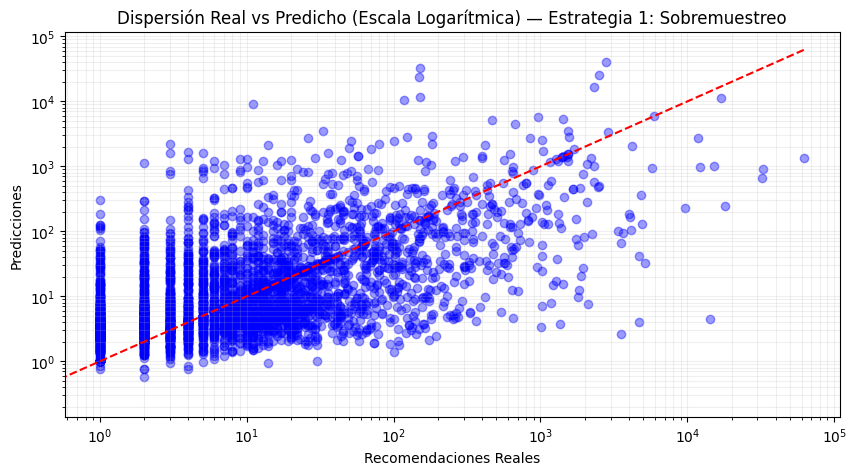


--- DICCIONARIO PARA TU SCRIPT DE WANDB ---
{'usar_Family Sharing': False, 'usar_Free To Play': True, 'usar_yt_score': True, 'usar_Steam Trading Cards': False, 'usar_price_overview': True, 'usar_Steam Cloud': True, 'usar_num_languages': True, 'usar_Steam Achievements': True, 'usar_RPG': True, 'usar_Online Co-op': False, 'usar_Casual': True, 'usar_Custom Volume Controls': True, 'usar_Simulation': True, 'usar_release_year': True, 'usar_Co-op': False, 'usar_Multi-player': False, 'usar_Shared/Split Screen': True, 'usar_Playable without Timed Input': True, 'usar_total_games_by_publisher': True, 'n_neighbors': 10, 'weights': 'distance', 'p': 1, 'dim_reduction': 'pca'}


In [14]:
df_prepared = _preprocess(df, use_images=True)
X = df_prepared.drop(columns=['recomendaciones_totales'])
y = df_prepared['recomendaciones_totales']

bins_strat = [-1, 10, 100, 1000, 10000, float('inf')]
y_binned = pd.cut(y, bins=bins_strat, labels=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y_binned
)

top_tabular_variables = [
    'Family Sharing', 'Free To Play', 'yt_score', 'Steam Trading Cards',
    'price_overview', 'Steam Cloud', 'num_languages', 'Steam Achievements',
    'RPG', 'Online Co-op', 'Casual', 'Custom Volume Controls',
    'Simulation', 'release_year', 'Co-op', 'Multi-player', 'Shared/Split Screen',
    'Playable without Timed Input', 'total_games_by_publisher'
]

# ─────────────────────────────────────────────
# OPTUNA (sin cambios respecto a tu código)
# ─────────────────────────────────────────────
def objective(trial, X_t, y_t):
    img_cols = [c for c in X_t.columns if c.startswith('v_clip_')]
    tabular_cols = [c for c in top_tabular_variables if c in X_t.columns]

    variables_elegidas = [col for col in tabular_cols if trial.suggest_categorical(f'usar_{col}', [True, False])]
    if len(variables_elegidas) == 0:
        return float('inf')

    columnas_finales = variables_elegidas + img_cols
    X_filtrada = X_t[columnas_finales]

    n_neighbors = trial.suggest_int('n_neighbors', 3, 50)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    p = trial.suggest_int('p', 1, 2)

    todas_sesgadas = ['price_overview', 'num_languages', 'total_games_by_publisher']
    cols_sesgadas = [c for c in variables_elegidas if c in todas_sesgadas]
    cols_binarias = [c for c in variables_elegidas if set(X_t[c].dropna().unique()).issubset({0, 1, 0.0, 1.0})]
    cols_normales = [c for c in variables_elegidas if c not in cols_sesgadas + cols_binarias]

    transformers_list = [
        ('sesgadas', PowerTransformer(method='yeo-johnson'), cols_sesgadas),
        ('normales', StandardScaler(), cols_normales),
        ('binarias', 'passthrough', cols_binarias)
    ]

    if len(img_cols) > 0:
        dim_reduction = trial.suggest_categorical('dim_reduction', ['pca', 'umap'])
        if dim_reduction == 'pca':
            reducer = PCA(n_components=10, random_state=42)
        else:
            reducer = UMAP(
                n_components=10,
                n_neighbors=trial.suggest_int('umap_n_neighbors', 5, 50),
                min_dist=trial.suggest_float('umap_min_dist', 0.0, 0.5),
                random_state=42
            )
        transformers_list.append(('reducer', reducer, img_cols))

    preprocessor = ColumnTransformer(transformers=transformers_list, remainder='drop')
    pipeline = Pipeline([
        ('prep', preprocessor),
        ('knn', KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights, p=p, n_jobs=-1))
    ])
    final_model = TransformedTargetRegressor(regressor=pipeline, func=np.log1p, inverse_func=np.expm1)

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_validate(final_model, X_filtrada, y_t, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
    return -scores['test_score'].mean()


print("Iniciando optimización de 300 trials...")
study = optuna.create_study(direction='minimize')
study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=300)

mejores_parametros = study.best_params
img_cols = [c for c in X_train.columns if c.startswith('v_clip_')]
variables_ganadoras = [col for col in top_tabular_variables if mejores_parametros.get(f'usar_{col}') == True]

X_train_final = X_train[variables_ganadoras + img_cols]
X_test_final  = X_test[variables_ganadoras + img_cols]

# ─────────────────────────────────────────────
# ESTRATEGIA 1: SOBREMUESTREO DE JUEGOS POPULARES
# Duplicamos los ejemplos en rangos altos para que el KNN
# tenga más vecinos "comparables" cuando predice esos rangos.
# ─────────────────────────────────────────────
print("\nAplicando sobremuestreo por rango de popularidad...")

# (rango_bajo, rango_alto, factor de duplicación)
rangos_oversample = [
    (100,   1_000,   3),
    (1_000, 10_000,  8),
    (10_000, float('inf'), 20),
]

X_train_aug_parts = [X_train_final]
y_train_aug_parts = [y_train]

for low, high, factor in rangos_oversample:
    mask = (y_train > low) & (y_train <= high)
    n_en_rango = mask.sum()
    if n_en_rango == 0:
        continue
    print(f"  Rango ({low:,} – {'∞' if high == float('inf') else f'{high:,}'}): "
          f"{n_en_rango} juegos → {n_en_rango * factor} copias (×{factor})")
    X_res, y_res = resample(
        X_train_final[mask], y_train[mask],
        n_samples=n_en_rango * factor,
        random_state=42,
        replace=True
    )
    X_train_aug_parts.append(X_res)
    y_train_aug_parts.append(y_res)

X_train_aug = pd.concat(X_train_aug_parts).reset_index(drop=True)
y_train_aug = pd.concat(y_train_aug_parts).reset_index(drop=True)
print(f"\nTamaño train original: {len(X_train_final):,}  →  aumentado: {len(X_train_aug):,}")

# ─────────────────────────────────────────────
# CONSTRUCCIÓN DEL PIPELINE FINAL (igual que antes)
# ─────────────────────────────────────────────
todas_sesgadas = ['price_overview', 'num_languages', 'total_games_by_publisher']
cols_sesgadas = [c for c in variables_ganadoras if c in todas_sesgadas]
cols_binarias = [c for c in variables_ganadoras if set(X_train[c].dropna().unique()).issubset({0, 1, 0.0, 1.0})]
cols_normales = [c for c in variables_ganadoras if c not in cols_sesgadas + cols_binarias]

final_transformers = [
    ('sesgadas', PowerTransformer(method='yeo-johnson'), cols_sesgadas),
    ('normales', StandardScaler(), cols_normales),
    ('binarias', 'passthrough', cols_binarias)
]

if mejores_parametros.get('dim_reduction') == 'pca':
    final_reducer = PCA(n_components=10, random_state=42)
else:
    final_reducer = UMAP(
        n_components=10,
        n_neighbors=mejores_parametros['umap_n_neighbors'],
        min_dist=mejores_parametros['umap_min_dist'],
        random_state=42
    )
final_transformers.append(('reducer', final_reducer, img_cols))

final_pipeline = Pipeline([
    ('prep', ColumnTransformer(transformers=final_transformers, remainder='drop')),
    ('knn', KNeighborsRegressor(
        n_neighbors=mejores_parametros['n_neighbors'],
        weights=mejores_parametros['weights'],
        p=mejores_parametros['p'],
        n_jobs=-1
    ))
])

modelo_definitivo = TransformedTargetRegressor(
    regressor=final_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

# ─── Entrenamos con los datos AUMENTADOS ───
modelo_definitivo.fit(X_train_aug, y_train_aug)
predicciones = modelo_definitivo.predict(X_test_final)

# ─────────────────────────────────────────────
# MÉTRICAS
# ─────────────────────────────────────────────
print("\n--- MÉTRICAS GENERALES EN TEST ---")
get_metrics(y_test, predicciones)


def check_performance_by_bins(y_real, y_pred):
    results = pd.DataFrame({'Real': y_real, 'Pred': y_pred})
    bins   = [-1, 10, 100, 1000, 10000, float('inf')]
    labels = ['0-10', '10-100', '100-1k', '1k-10k', '>10k']
    results['Rango'] = pd.cut(results['Real'], bins=bins, labels=labels)

    performance = results.groupby('Rango', observed=True).apply(
        lambda x: mean_absolute_error(x['Real'], x['Pred']) if len(x) > 0 else 0
    )

    print("\n--- MAE POR RANGO DE POPULARIDAD ---")
    print(performance)

    plt.figure(figsize=(10, 5))
    plt.scatter(y_real, y_pred, alpha=0.4, color='blue')
    plt.plot([y_real.min(), y_real.max()], [y_real.min(), y_real.max()], 'r--')
    plt.xscale('log'); plt.yscale('log')
    plt.title('Dispersión Real vs Predicho (Escala Logarítmica) — Estrategia 1: Sobremuestreo')
    plt.xlabel('Recomendaciones Reales'); plt.ylabel('Predicciones')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()


check_performance_by_bins(y_test, predicciones)

print("\n--- DICCIONARIO PARA TU SCRIPT DE WANDB ---")
print(mejores_parametros)

Iniciando optimización de 300 trials...

Entrenando clasificador de popularidad (GradientBoosting)...
Accuracy del clasificador en test: 0.667

Entrenando regresor KNN por cada rango de popularidad...
  Bin 0-10: entrenado con 9782 ejemplos
  Bin 10-100: entrenado con 4551 ejemplos
  Bin 100-1k: entrenado con 1311 ejemplos
  Bin 1k-10k: entrenado con 317 ejemplos
  Bin >10k: entrenado con 35 ejemplos

Entrenando modelo global (fallback para bins sin modelo)...

--- MÉTRICAS GENERALES EN TEST ---
MAE (Error Absoluto Medio): 136.8292
RMSE (Raíz del Error Cuadrático Medio): 1372.5137
R2 Score (Coef. de Determinación): 0.0508

--- MAE POR RANGO DE POPULARIDAD ---
Rango
0-10         15.652767
10-100       41.067208
100-1k      314.511839
1k-10k     2488.044907
>10k      18064.489274
dtype: float64


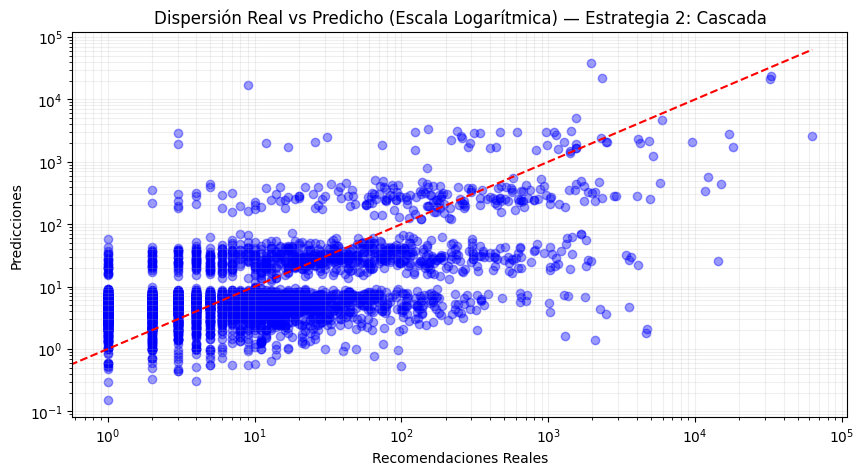


--- DICCIONARIO PARA TU SCRIPT DE WANDB ---
{'usar_Family Sharing': False, 'usar_Free To Play': True, 'usar_yt_score': True, 'usar_Steam Trading Cards': True, 'usar_price_overview': True, 'usar_Steam Cloud': True, 'usar_num_languages': True, 'usar_Steam Achievements': True, 'usar_RPG': False, 'usar_Online Co-op': True, 'usar_Casual': False, 'usar_Custom Volume Controls': False, 'usar_Simulation': True, 'usar_release_year': False, 'usar_Co-op': False, 'usar_Multi-player': True, 'usar_Shared/Split Screen': True, 'usar_Playable without Timed Input': True, 'usar_total_games_by_publisher': True, 'n_neighbors': 5, 'weights': 'distance', 'p': 1, 'dim_reduction': 'umap', 'umap_n_neighbors': 32, 'umap_min_dist': 0.42624549648306065}


In [15]:
df_prepared = _preprocess(df, use_images=True)
X = df_prepared.drop(columns=['recomendaciones_totales'])
y = df_prepared['recomendaciones_totales']

bins_strat = [-1, 10, 100, 1000, 10000, float('inf')]
y_binned = pd.cut(y, bins=bins_strat, labels=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y_binned
)

top_tabular_variables = [
    'Family Sharing', 'Free To Play', 'yt_score', 'Steam Trading Cards',
    'price_overview', 'Steam Cloud', 'num_languages', 'Steam Achievements',
    'RPG', 'Online Co-op', 'Casual', 'Custom Volume Controls',
    'Simulation', 'release_year', 'Co-op', 'Multi-player', 'Shared/Split Screen',
    'Playable without Timed Input', 'total_games_by_publisher'
]

# ─────────────────────────────────────────────
# OPTUNA
# ─────────────────────────────────────────────
def objective(trial, X_t, y_t):
    img_cols = [c for c in X_t.columns if c.startswith('v_clip_')]
    tabular_cols = [c for c in top_tabular_variables if c in X_t.columns]

    variables_elegidas = [col for col in tabular_cols if trial.suggest_categorical(f'usar_{col}', [True, False])]
    if len(variables_elegidas) == 0:
        return float('inf')

    columnas_finales = variables_elegidas + img_cols
    X_filtrada = X_t[columnas_finales]

    n_neighbors = trial.suggest_int('n_neighbors', 3, 50)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    p = trial.suggest_int('p', 1, 2)

    todas_sesgadas = ['price_overview', 'num_languages', 'total_games_by_publisher']
    cols_sesgadas = [c for c in variables_elegidas if c in todas_sesgadas]
    cols_binarias = [c for c in variables_elegidas if set(X_t[c].dropna().unique()).issubset({0, 1, 0.0, 1.0})]
    cols_normales = [c for c in variables_elegidas if c not in cols_sesgadas + cols_binarias]

    transformers_list = [
        ('sesgadas', PowerTransformer(method='yeo-johnson'), cols_sesgadas),
        ('normales', StandardScaler(), cols_normales),
        ('binarias', 'passthrough', cols_binarias)
    ]

    if len(img_cols) > 0:
        dim_reduction = trial.suggest_categorical('dim_reduction', ['pca', 'umap'])
        if dim_reduction == 'pca':
            reducer = PCA(n_components=10, random_state=42)
        else:
            reducer = UMAP(
                n_components=10,
                n_neighbors=trial.suggest_int('umap_n_neighbors', 5, 50),
                min_dist=trial.suggest_float('umap_min_dist', 0.0, 0.5),
                random_state=42
            )
        transformers_list.append(('reducer', reducer, img_cols))

    preprocessor = ColumnTransformer(transformers=transformers_list, remainder='drop')
    pipeline = Pipeline([
        ('prep', preprocessor),
        ('knn', KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights, p=p, n_jobs=-1))
    ])
    final_model = TransformedTargetRegressor(regressor=pipeline, func=np.log1p, inverse_func=np.expm1)

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_validate(final_model, X_filtrada, y_t, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
    return -scores['test_score'].mean()


print("Iniciando optimización de 300 trials...")
study = optuna.create_study(direction='minimize')
study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=300)

mejores_parametros = study.best_params
img_cols = [c for c in X_train.columns if c.startswith('v_clip_')]
variables_ganadoras = [col for col in top_tabular_variables if mejores_parametros.get(f'usar_{col}') == True]

X_train_final = X_train[variables_ganadoras + img_cols]
X_test_final  = X_test[variables_ganadoras + img_cols]

# ─────────────────────────────────────────────
# PIPELINE BASE (el mismo KNN tuneado, se clonará por bin)
# ─────────────────────────────────────────────
todas_sesgadas = ['price_overview', 'num_languages', 'total_games_by_publisher']
cols_sesgadas = [c for c in variables_ganadoras if c in todas_sesgadas]
cols_binarias = [c for c in variables_ganadoras if set(X_train[c].dropna().unique()).issubset({0, 1, 0.0, 1.0})]
cols_normales = [c for c in variables_ganadoras if c not in cols_sesgadas + cols_binarias]

final_transformers = [
    ('sesgadas', PowerTransformer(method='yeo-johnson'), cols_sesgadas),
    ('normales', StandardScaler(), cols_normales),
    ('binarias', 'passthrough', cols_binarias)
]

if mejores_parametros.get('dim_reduction') == 'pca':
    final_reducer = PCA(n_components=10, random_state=42)
else:
    final_reducer = UMAP(
        n_components=10,
        n_neighbors=mejores_parametros['umap_n_neighbors'],
        min_dist=mejores_parametros['umap_min_dist'],
        random_state=42
    )
final_transformers.append(('reducer', final_reducer, img_cols))

pipeline_base = Pipeline([
    ('prep', ColumnTransformer(transformers=final_transformers, remainder='drop')),
    ('knn', KNeighborsRegressor(
        n_neighbors=mejores_parametros['n_neighbors'],
        weights=mejores_parametros['weights'],
        p=mejores_parametros['p'],
        n_jobs=-1
    ))
])

modelo_base = TransformedTargetRegressor(
    regressor=pipeline_base,
    func=np.log1p,
    inverse_func=np.expm1
)

# ─────────────────────────────────────────────
# ESTRATEGIA 2: CASCADA CLASIFICADOR + REGRESOR POR BIN
#
# Idea: primero un GBM predice en qué rango de popularidad cae
# el juego; luego se aplica el KNN especializado en ese rango.
# Cada KNN solo ha visto ejemplos de su propio rango, por lo que
# sus vecinos siempre son comparables entre sí.
# ─────────────────────────────────────────────

BINS   = [-1, 10, 100, 1000, 10000, float('inf')]
LABELS = [0, 1, 2, 3, 4]
NOMBRES = ['0-10', '10-100', '100-1k', '1k-10k', '>10k']

# ── Paso 1: Clasificador de bin (solo features tabulares, sin imágenes,
#            para que sea rápido y no sobrefit sobre la estructura de img) ──
y_train_bin = pd.cut(y_train, bins=BINS, labels=LABELS).astype(int)
y_test_bin  = pd.cut(y_test,  bins=BINS, labels=LABELS).astype(int)

print("\nEntrenando clasificador de popularidad (GradientBoosting)...")
clf = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
clf.fit(X_train_final[variables_ganadoras], y_train_bin)

acc = (clf.predict(X_test_final[variables_ganadoras]) == y_test_bin).mean()
print(f"Accuracy del clasificador en test: {acc:.3f}")

# ── Paso 2: Un regresor KNN independiente por cada bin ──
print("\nEntrenando regresor KNN por cada rango de popularidad...")
modelos_por_bin = {}

for b, nombre in zip(LABELS, NOMBRES):
    mask_train = y_train_bin == b
    n = mask_train.sum()

    if n < 5:
        print(f"  Bin {nombre}: solo {n} ejemplos — se omite (se usará el modelo global)")
        continue

    # Clonamos el pipeline base para no compartir estado entre bins
    modelo_bin = clone(modelo_base)
    modelo_bin.fit(X_train_final[mask_train], y_train[mask_train])
    modelos_por_bin[b] = modelo_bin
    print(f"  Bin {nombre}: entrenado con {n} ejemplos")

# ── Entrenamos también el modelo global como fallback ──
print("\nEntrenando modelo global (fallback para bins sin modelo)...")
modelo_global = clone(modelo_base)
modelo_global.fit(X_train_final, y_train)

# ── Paso 3: Inferencia en cascada ──
def predict_cascade(X_tab, X_full):
    """
    1. El clasificador asigna un bin a cada juego.
    2. El regresor especializado de ese bin hace la predicción.
    3. Si no existe regresor para ese bin, usa el global.
    """
    bins_predichos = clf.predict(X_tab[variables_ganadoras])
    predicciones = np.zeros(len(X_full))

    for b in set(bins_predichos):
        mask = bins_predichos == b
        if b in modelos_por_bin:
            predicciones[mask] = modelos_por_bin[b].predict(X_full[mask])
        else:
            predicciones[mask] = modelo_global.predict(X_full[mask])

    return predicciones


predicciones = predict_cascade(X_test_final, X_test_final)

# ─────────────────────────────────────────────
# MÉTRICAS
# ─────────────────────────────────────────────
print("\n--- MÉTRICAS GENERALES EN TEST ---")
get_metrics(y_test, predicciones)


def check_performance_by_bins(y_real, y_pred):
    results = pd.DataFrame({'Real': y_real, 'Pred': y_pred})
    bins   = [-1, 10, 100, 1000, 10000, float('inf')]
    labels = ['0-10', '10-100', '100-1k', '1k-10k', '>10k']
    results['Rango'] = pd.cut(results['Real'], bins=bins, labels=labels)

    performance = results.groupby('Rango', observed=True).apply(
        lambda x: mean_absolute_error(x['Real'], x['Pred']) if len(x) > 0 else 0
    )

    print("\n--- MAE POR RANGO DE POPULARIDAD ---")
    print(performance)

    plt.figure(figsize=(10, 5))
    plt.scatter(y_real, y_pred, alpha=0.4, color='blue')
    plt.plot([y_real.min(), y_real.max()], [y_real.min(), y_real.max()], 'r--')
    plt.xscale('log'); plt.yscale('log')
    plt.title('Dispersión Real vs Predicho (Escala Logarítmica) — Estrategia 2: Cascada')
    plt.xlabel('Recomendaciones Reales'); plt.ylabel('Predicciones')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()


check_performance_by_bins(y_test, predicciones)

print("\n--- DICCIONARIO PARA TU SCRIPT DE WANDB ---")
print(mejores_parametros)

Iniciando optimización de 300 trials (con RMSLE)...

--- MÉTRICAS GENERALES EN TEST ---
MAE (Error Absoluto Medio): 119.6807
RMSE (Raíz del Error Cuadrático Medio): 1377.5597
R2 Score (Coef. de Determinación): 0.0438
RMSLE (métrica de optimización): 1.2513

--- MAE POR RANGO DE POPULARIDAD ---
Rango
0-10          4.412908
10-100       21.170635
100-1k      235.395352
1k-10k     1963.027660
>10k      23505.308432
dtype: float64


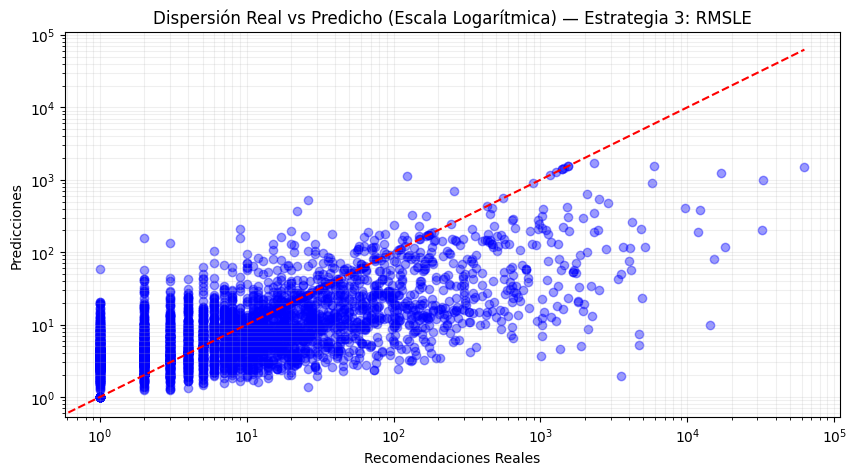


--- DICCIONARIO PARA TU SCRIPT DE WANDB ---
{'usar_Family Sharing': True, 'usar_Free To Play': True, 'usar_yt_score': True, 'usar_Steam Trading Cards': False, 'usar_price_overview': True, 'usar_Steam Cloud': True, 'usar_num_languages': True, 'usar_Steam Achievements': True, 'usar_RPG': True, 'usar_Online Co-op': True, 'usar_Casual': True, 'usar_Custom Volume Controls': False, 'usar_Simulation': True, 'usar_release_year': True, 'usar_Co-op': False, 'usar_Multi-player': True, 'usar_Shared/Split Screen': False, 'usar_Playable without Timed Input': False, 'usar_total_games_by_publisher': True, 'n_neighbors': 22, 'weights': 'distance', 'p': 1, 'dim_reduction': 'pca'}


In [7]:
df_prepared = _preprocess(df, use_images=True)
X = df_prepared.drop(columns=['recomendaciones_totales'])
y = df_prepared['recomendaciones_totales']

bins_strat = [-1, 10, 100, 1000, 10000, float('inf')]
y_binned = pd.cut(y, bins=bins_strat, labels=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y_binned
)

top_tabular_variables = [
    'Family Sharing', 'Free To Play', 'yt_score', 'Steam Trading Cards',
    'price_overview', 'Steam Cloud', 'num_languages', 'Steam Achievements',
    'RPG', 'Online Co-op', 'Casual', 'Custom Volume Controls',
    'Simulation', 'release_year', 'Co-op', 'Multi-player', 'Shared/Split Screen',
    'Playable without Timed Input', 'total_games_by_publisher'
]

# ─────────────────────────────────────────────
# ESTRATEGIA 3: RMSLE COMO MÉTRICA DE OPTIMIZACIÓN
#
# El MAE pesa un error de 1000 en un juego con 1k reseñas igual que
# en uno con 100k. El RMSLE trabaja en escala logarítmica, así que un
# error relativo del 50% pesa lo mismo sin importar el rango absoluto.
# Esto obliga a Optuna a buscar hiperparámetros que también funcionen
# bien en los juegos más populares.
# ─────────────────────────────────────────────

def rmsle_scorer(y_true, y_pred):
    """RMSLE clipeando negativos por si el modelo devuelve algo negativo."""
    y_pred_safe = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred_safe))


def objective(trial, X_t, y_t):
    img_cols = [c for c in X_t.columns if c.startswith('v_clip_')]
    tabular_cols = [c for c in top_tabular_variables if c in X_t.columns]

    variables_elegidas = [col for col in tabular_cols if trial.suggest_categorical(f'usar_{col}', [True, False])]
    if len(variables_elegidas) == 0:
        return float('inf')

    columnas_finales = variables_elegidas + img_cols
    X_filtrada = X_t[columnas_finales]

    n_neighbors = trial.suggest_int('n_neighbors', 3, 50)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    p = trial.suggest_int('p', 1, 2)

    todas_sesgadas = ['price_overview', 'num_languages', 'total_games_by_publisher']
    cols_sesgadas = [c for c in variables_elegidas if c in todas_sesgadas]
    cols_binarias = [c for c in variables_elegidas if set(X_t[c].dropna().unique()).issubset({0, 1, 0.0, 1.0})]
    cols_normales = [c for c in variables_elegidas if c not in cols_sesgadas + cols_binarias]

    transformers_list = [
        ('sesgadas', PowerTransformer(method='yeo-johnson'), cols_sesgadas),
        ('normales', StandardScaler(), cols_normales),
        ('binarias', 'passthrough', cols_binarias)
    ]

    if len(img_cols) > 0:
        dim_reduction = trial.suggest_categorical('dim_reduction', ['pca', 'umap'])
        if dim_reduction == 'pca':
            reducer = PCA(n_components=10, random_state=42)
        else:
            reducer = UMAP(
                n_components=10,
                n_neighbors=trial.suggest_int('umap_n_neighbors', 5, 50),
                min_dist=trial.suggest_float('umap_min_dist', 0.0, 0.5),
                random_state=42
            )
        transformers_list.append(('reducer', reducer, img_cols))

    preprocessor = ColumnTransformer(transformers=transformers_list, remainder='drop')
    pipeline = Pipeline([
        ('prep', preprocessor),
        ('knn', KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights, p=p, n_jobs=-1))
    ])
    final_model = TransformedTargetRegressor(regressor=pipeline, func=np.log1p, inverse_func=np.expm1)

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    # ── CAMBIO CLAVE: scoring = neg_mean_squared_log_error en lugar de neg_MAE ──
    scores = cross_validate(
        final_model, X_filtrada, y_t,
        cv=cv,
        scoring='neg_mean_squared_log_error',   # <── aquí está el cambio
        n_jobs=-1
    )
    # Optuna minimiza, devolvemos RMSLE (positivo)
    return np.sqrt(-scores['test_score'].mean())


print("Iniciando optimización de 300 trials (con RMSLE)...")
study = optuna.create_study(direction='minimize')
study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=300)

mejores_parametros = study.best_params
img_cols = [c for c in X_train.columns if c.startswith('v_clip_')]
variables_ganadoras = [col for col in top_tabular_variables if mejores_parametros.get(f'usar_{col}') == True]

X_train_final = X_train[variables_ganadoras + img_cols]
X_test_final  = X_test[variables_ganadoras + img_cols]

# ─────────────────────────────────────────────
# CONSTRUCCIÓN DEL PIPELINE FINAL
# ─────────────────────────────────────────────
todas_sesgadas = ['price_overview', 'num_languages', 'total_games_by_publisher']
cols_sesgadas = [c for c in variables_ganadoras if c in todas_sesgadas]
cols_binarias = [c for c in variables_ganadoras if set(X_train[c].dropna().unique()).issubset({0, 1, 0.0, 1.0})]
cols_normales = [c for c in variables_ganadoras if c not in cols_sesgadas + cols_binarias]

final_transformers = [
    ('sesgadas', PowerTransformer(method='yeo-johnson'), cols_sesgadas),
    ('normales', StandardScaler(), cols_normales),
    ('binarias', 'passthrough', cols_binarias)
]

if mejores_parametros.get('dim_reduction') == 'pca':
    final_reducer = PCA(n_components=10, random_state=42)
else:
    final_reducer = UMAP(
        n_components=10,
        n_neighbors=mejores_parametros['umap_n_neighbors'],
        min_dist=mejores_parametros['umap_min_dist'],
        random_state=42
    )
final_transformers.append(('reducer', final_reducer, img_cols))

final_pipeline = Pipeline([
    ('prep', ColumnTransformer(transformers=final_transformers, remainder='drop')),
    ('knn', KNeighborsRegressor(
        n_neighbors=mejores_parametros['n_neighbors'],
        weights=mejores_parametros['weights'],
        p=mejores_parametros['p'],
        n_jobs=-1
    ))
])

modelo_definitivo = TransformedTargetRegressor(
    regressor=final_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

modelo_definitivo.fit(X_train_final, y_train)
predicciones = modelo_definitivo.predict(X_test_final)

# ─────────────────────────────────────────────
# MÉTRICAS — mostramos tanto MAE como RMSLE
# ─────────────────────────────────────────────
print("\n--- MÉTRICAS GENERALES EN TEST ---")
get_metrics(y_test, predicciones)

rmsle_test = rmsle_scorer(y_test, predicciones)
print(f"RMSLE (métrica de optimización): {rmsle_test:.4f}")


def check_performance_by_bins(y_real, y_pred):
    results = pd.DataFrame({'Real': y_real, 'Pred': y_pred})
    bins   = [-1, 10, 100, 1000, 10000, float('inf')]
    labels = ['0-10', '10-100', '100-1k', '1k-10k', '>10k']
    results['Rango'] = pd.cut(results['Real'], bins=bins, labels=labels)

    performance = results.groupby('Rango', observed=True).apply(
        lambda x: mean_absolute_error(x['Real'], x['Pred']) if len(x) > 0 else 0
    )

    print("\n--- MAE POR RANGO DE POPULARIDAD ---")
    print(performance)

    plt.figure(figsize=(10, 5))
    plt.scatter(y_real, y_pred, alpha=0.4, color='blue')
    plt.plot([y_real.min(), y_real.max()], [y_real.min(), y_real.max()], 'r--')
    plt.xscale('log'); plt.yscale('log')
    plt.title('Dispersión Real vs Predicho (Escala Logarítmica) — Estrategia 3: RMSLE')
    plt.xlabel('Recomendaciones Reales'); plt.ylabel('Predicciones')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()


check_performance_by_bins(y_test, predicciones)

print("\n--- DICCIONARIO PARA TU SCRIPT DE WANDB ---")
print(mejores_parametros)

Iniciando optimización de 300 trials (con LogKNN)...

--- MÉTRICAS GENERALES EN TEST ---
MAE (Error Absoluto Medio): 121.8357
RMSE (Raíz del Error Cuadrático Medio): 1374.1997
R2 Score (Coef. de Determinación): 0.0485

--- MAE POR RANGO DE POPULARIDAD ---
Rango
0-10          6.359391
10-100       28.150770
100-1k      246.552949
1k-10k     1904.495674
>10k      23158.615460
dtype: float64


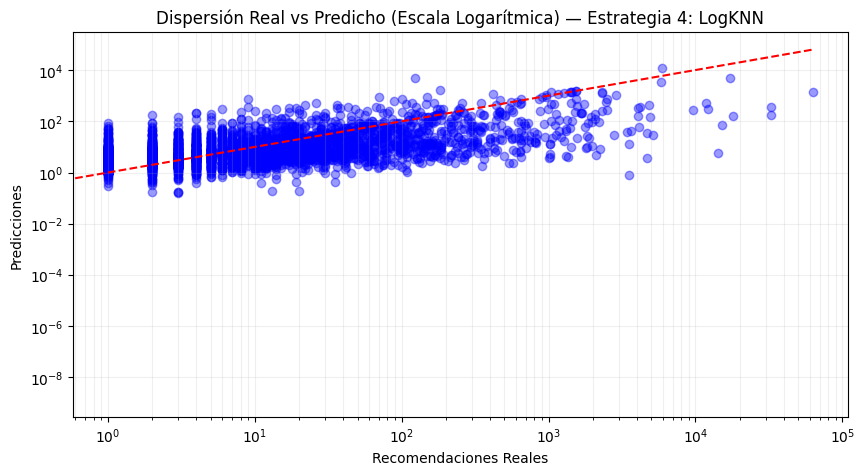


--- DICCIONARIO PARA TU SCRIPT DE WANDB ---
{'usar_Family Sharing': True, 'usar_Free To Play': False, 'usar_yt_score': True, 'usar_Steam Trading Cards': True, 'usar_price_overview': True, 'usar_Steam Cloud': True, 'usar_num_languages': True, 'usar_Steam Achievements': False, 'usar_RPG': True, 'usar_Online Co-op': False, 'usar_Casual': True, 'usar_Custom Volume Controls': True, 'usar_Simulation': False, 'usar_release_year': True, 'usar_Co-op': False, 'usar_Multi-player': False, 'usar_Shared/Split Screen': False, 'usar_Playable without Timed Input': False, 'usar_total_games_by_publisher': True, 'n_neighbors': 4, 'weights': 'distance', 'p': 1, 'dim_reduction': 'pca'}


In [8]:
df_prepared = _preprocess(df, use_images=True)
X = df_prepared.drop(columns=['recomendaciones_totales'])
y = df_prepared['recomendaciones_totales']

bins_strat = [-1, 10, 100, 1000, 10000, float('inf')]
y_binned = pd.cut(y, bins=bins_strat, labels=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y_binned
)

top_tabular_variables = [
    'Family Sharing', 'Free To Play', 'yt_score', 'Steam Trading Cards',
    'price_overview', 'Steam Cloud', 'num_languages', 'Steam Achievements',
    'RPG', 'Online Co-op', 'Casual', 'Custom Volume Controls',
    'Simulation', 'release_year', 'Co-op', 'Multi-player', 'Shared/Split Screen',
    'Playable without Timed Input', 'total_games_by_publisher'
]

# ─────────────────────────────────────────────
# ESTRATEGIA 4: LogKNN — promedio en escala log del target
#
# El KNN estándar promedia los targets de los vecinos en escala lineal.
# Si un vecino tiene 500 reseñas y otro tiene 50 000, el promedio es
# ~25 000 y ninguno de los dos queda bien representado.
#
# LogKNN guarda los targets en escala log durante el fit y promedia
# también en log durante el predict, devolviendo exp(promedio_log).
# Esto es equivalente a la media geométrica, mucho más robusta con
# distribuciones tan sesgadas como la de reseñas de videojuegos.
# ─────────────────────────────────────────────

class LogKNN(KNeighborsRegressor):
    """
    KNN que internaliza el target en escala logarítmica.

    - fit():     guarda log1p(y) en self._y_log
    - predict(): encuentra vecinos, promedia log1p(y_vecinos)
                 y devuelve expm1(promedio)   →  media geométrica efectiva
    - Compatible con Pipeline y cross_validate de sklearn.
    """

    def fit(self, X, y):
        # Guardamos el target original para que el pipeline pueda
        # llamar a super().fit() con él (lo necesita internamente)
        self._y_log = np.log1p(np.asarray(y, dtype=float))
        # Llamamos al fit de KNeighborsRegressor con y normal
        # (solo nos interesa que construya el índice KD-tree)
        super().fit(X, y)
        # Sobreescribimos _y con la versión log para que predict use log
        self._y = self._y_log
        return self

    def predict(self, X):
        # kneighbors devuelve distancias e índices de los k vecinos
        neigh_dist, neigh_ind = self.kneighbors(X)

        # Targets de los vecinos ya están en escala log (self._y = self._y_log)
        y_neigh_log = self._y[neigh_ind]

        if self.weights == 'distance':
            # Evitamos división por cero cuando dist == 0 (predicción exacta)
            w = 1.0 / (neigh_dist + 1e-8)
            pred_log = np.average(y_neigh_log, weights=w, axis=1)
        else:
            pred_log = y_neigh_log.mean(axis=1)

        # Volvemos a escala original
        return np.expm1(pred_log)


def objective(trial, X_t, y_t):
    img_cols = [c for c in X_t.columns if c.startswith('v_clip_')]
    tabular_cols = [c for c in top_tabular_variables if c in X_t.columns]

    variables_elegidas = [col for col in tabular_cols if trial.suggest_categorical(f'usar_{col}', [True, False])]
    if len(variables_elegidas) == 0:
        return float('inf')

    columnas_finales = variables_elegidas + img_cols
    X_filtrada = X_t[columnas_finales]

    n_neighbors = trial.suggest_int('n_neighbors', 3, 50)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    p = trial.suggest_int('p', 1, 2)

    todas_sesgadas = ['price_overview', 'num_languages', 'total_games_by_publisher']
    cols_sesgadas = [c for c in variables_elegidas if c in todas_sesgadas]
    cols_binarias = [c for c in variables_elegidas if set(X_t[c].dropna().unique()).issubset({0, 1, 0.0, 1.0})]
    cols_normales = [c for c in variables_elegidas if c not in cols_sesgadas + cols_binarias]

    transformers_list = [
        ('sesgadas', PowerTransformer(method='yeo-johnson'), cols_sesgadas),
        ('normales', StandardScaler(), cols_normales),
        ('binarias', 'passthrough', cols_binarias)
    ]

    if len(img_cols) > 0:
        dim_reduction = trial.suggest_categorical('dim_reduction', ['pca', 'umap'])
        if dim_reduction == 'pca':
            reducer = PCA(n_components=10, random_state=42)
        else:
            reducer = UMAP(
                n_components=10,
                n_neighbors=trial.suggest_int('umap_n_neighbors', 5, 50),
                min_dist=trial.suggest_float('umap_min_dist', 0.0, 0.5),
                random_state=42
            )
        transformers_list.append(('reducer', reducer, img_cols))

    preprocessor = ColumnTransformer(transformers=transformers_list, remainder='drop')

    # ── CAMBIO CLAVE: usamos LogKNN en lugar de KNeighborsRegressor ──
    pipeline = Pipeline([
        ('prep', preprocessor),
        ('knn', LogKNN(n_neighbors=n_neighbors, weights=weights, p=p, n_jobs=-1))
    ])

    # LogKNN ya hace log/exp internamente, así que NO necesitamos
    # TransformedTargetRegressor. Si lo añadiéramos haríamos doble log.
    final_model = pipeline

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_validate(final_model, X_filtrada, y_t, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
    return -scores['test_score'].mean()


print("Iniciando optimización de 300 trials (con LogKNN)...")
study = optuna.create_study(direction='minimize')
study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=300)

mejores_parametros = study.best_params
img_cols = [c for c in X_train.columns if c.startswith('v_clip_')]
variables_ganadoras = [col for col in top_tabular_variables if mejores_parametros.get(f'usar_{col}') == True]

X_train_final = X_train[variables_ganadoras + img_cols]
X_test_final  = X_test[variables_ganadoras + img_cols]

# ─────────────────────────────────────────────
# CONSTRUCCIÓN DEL PIPELINE FINAL
# ─────────────────────────────────────────────
todas_sesgadas = ['price_overview', 'num_languages', 'total_games_by_publisher']
cols_sesgadas = [c for c in variables_ganadoras if c in todas_sesgadas]
cols_binarias = [c for c in variables_ganadoras if set(X_train[c].dropna().unique()).issubset({0, 1, 0.0, 1.0})]
cols_normales = [c for c in variables_ganadoras if c not in cols_sesgadas + cols_binarias]

final_transformers = [
    ('sesgadas', PowerTransformer(method='yeo-johnson'), cols_sesgadas),
    ('normales', StandardScaler(), cols_normales),
    ('binarias', 'passthrough', cols_binarias)
]

if mejores_parametros.get('dim_reduction') == 'pca':
    final_reducer = PCA(n_components=10, random_state=42)
else:
    final_reducer = UMAP(
        n_components=10,
        n_neighbors=mejores_parametros['umap_n_neighbors'],
        min_dist=mejores_parametros['umap_min_dist'],
        random_state=42
    )
final_transformers.append(('reducer', final_reducer, img_cols))

# ── Sin TransformedTargetRegressor — LogKNN gestiona la escala internamente ──
modelo_definitivo = Pipeline([
    ('prep', ColumnTransformer(transformers=final_transformers, remainder='drop')),
    ('knn', LogKNN(
        n_neighbors=mejores_parametros['n_neighbors'],
        weights=mejores_parametros['weights'],
        p=mejores_parametros['p'],
        n_jobs=-1
    ))
])

modelo_definitivo.fit(X_train_final, y_train)
predicciones = modelo_definitivo.predict(X_test_final)

# ─────────────────────────────────────────────
# MÉTRICAS
# ─────────────────────────────────────────────
print("\n--- MÉTRICAS GENERALES EN TEST ---")
get_metrics(y_test, predicciones)


def check_performance_by_bins(y_real, y_pred):
    results = pd.DataFrame({'Real': y_real, 'Pred': y_pred})
    bins   = [-1, 10, 100, 1000, 10000, float('inf')]
    labels = ['0-10', '10-100', '100-1k', '1k-10k', '>10k']
    results['Rango'] = pd.cut(results['Real'], bins=bins, labels=labels)

    performance = results.groupby('Rango', observed=True).apply(
        lambda x: mean_absolute_error(x['Real'], x['Pred']) if len(x) > 0 else 0
    )

    print("\n--- MAE POR RANGO DE POPULARIDAD ---")
    print(performance)

    plt.figure(figsize=(10, 5))
    plt.scatter(y_real, y_pred, alpha=0.4, color='blue')
    plt.plot([y_real.min(), y_real.max()], [y_real.min(), y_real.max()], 'r--')
    plt.xscale('log'); plt.yscale('log')
    plt.title('Dispersión Real vs Predicho (Escala Logarítmica) — Estrategia 4: LogKNN')
    plt.xlabel('Recomendaciones Reales'); plt.ylabel('Predicciones')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()


check_performance_by_bins(y_test, predicciones)

print("\n--- DICCIONARIO PARA TU SCRIPT DE WANDB ---")
print(mejores_parametros)

Iniciando optimización del Modelo Definitivo (LogKNN + RMSLE)...

---> TOP PARÁMETROS Y VARIABLES MÁS INFLUYENTES <---


,Parámetro,Importancia (%)
0,usar_price_overview,43.00
1,usar_yt_score,36.11
2,usar_Steam Cloud,3.93
3,usar_Steam Achievements,3.42
4,n_neighbors,3.06
5,usar_Casual,1.93
6,weights,1.49
7,usar_release_year,1.03
8,usar_Free To Play,0.95
9,usar_Online Co-op,0.79



--- MÉTRICAS GENERALES EN TEST ---
MAE General: 119.7152
RMSLE General (Métrica optimizada): 1.2423

--- MAE POR RANGO DE POPULARIDAD ---
Rango
0-10          5.083610
10-100       24.087363
100-1k      240.711118
1k-10k     1951.697843
>10k      22875.274390
dtype: float64


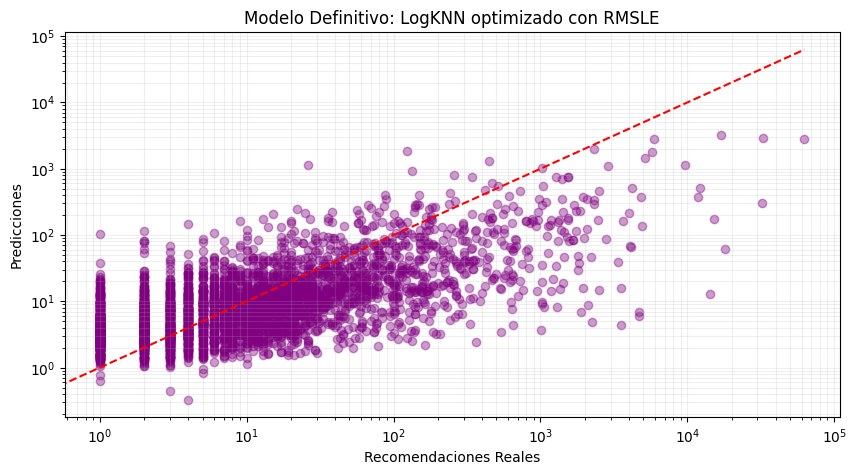


 📋 DICCIONARIO DE HIPERPARÁMETROS Y VARIABLES 
{'usar_Family Sharing': True, 'usar_Free To Play': True, 'usar_yt_score': True, 'usar_Steam Trading Cards': True, 'usar_price_overview': True, 'usar_Steam Cloud': True, 'usar_num_languages': True, 'usar_Steam Achievements': True, 'usar_RPG': True, 'usar_Online Co-op': False, 'usar_Casual': True, 'usar_Custom Volume Controls': False, 'usar_Simulation': True, 'usar_release_year': True, 'usar_Co-op': True, 'usar_Multi-player': True, 'usar_Shared/Split Screen': False, 'usar_Playable without Timed Input': False, 'usar_total_games_by_publisher': True, 'n_neighbors': 14, 'weights': 'distance', 'p': 1, 'dim_reduction': 'umap', 'umap_n_neighbors': 38, 'umap_min_dist': 0.19278894201475322}


In [11]:
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# =====================================================================
# 1. PREPARACIÓN DE DATOS
# =====================================================================
# Asumo que 'df' y la función '_preprocess' ya están definidos en tu entorno
df_prepared = _preprocess(df, use_images=True)
X = df_prepared.drop(columns=['recomendaciones_totales'])
y = df_prepared['recomendaciones_totales']

# Estratificación basada en el target
bins_strat = [-1, 10, 100, 1000, 10000, float('inf')]
y_binned = pd.cut(y, bins=bins_strat, labels=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y_binned
)

top_tabular_variables = [
    'Family Sharing', 'Free To Play', 'yt_score', 'Steam Trading Cards',
    'price_overview', 'Steam Cloud', 'num_languages', 'Steam Achievements',
    'RPG', 'Online Co-op', 'Casual', 'Custom Volume Controls',
    'Simulation', 'release_year', 'Co-op', 'Multi-player', 'Shared/Split Screen',
    'Playable without Timed Input', 'total_games_by_publisher'
]

# =====================================================================
# 2. CLASE LogKNN PERSONALIZADA
# =====================================================================
class LogKNN(KNeighborsRegressor):
    """
    KNN que internaliza el target en escala logarítmica.
    Promedia en log y devuelve expm1 (media geométrica).
    """
    def fit(self, X, y):
        self._y_log = np.log1p(np.asarray(y, dtype=float))
        super().fit(X, y)
        self._y = self._y_log
        return self

    def predict(self, X):
        neigh_dist, neigh_ind = self.kneighbors(X)
        y_neigh_log = self._y[neigh_ind]

        if self.weights == 'distance':
            w = 1.0 / (neigh_dist + 1e-8)
            pred_log = np.average(y_neigh_log, weights=w, axis=1)
        else:
            pred_log = y_neigh_log.mean(axis=1)

        return np.expm1(pred_log)

# =====================================================================
# 3. FUNCIÓN OBJETIVO (RMSLE) Y OPTUNA
# =====================================================================
def objective(trial, X_t, y_t):
    img_cols = [c for c in X_t.columns if c.startswith('v_clip_')]
    tabular_cols = [c for c in top_tabular_variables if c in X_t.columns]

    variables_elegidas = [col for col in tabular_cols if trial.suggest_categorical(f'usar_{col}', [True, False])]
    if len(variables_elegidas) == 0:
        return float('inf')

    columnas_finales = variables_elegidas + img_cols
    X_filtrada = X_t[columnas_finales]

    n_neighbors = trial.suggest_int('n_neighbors', 3, 50)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    p = trial.suggest_int('p', 1, 2)

    todas_sesgadas = ['price_overview', 'num_languages', 'total_games_by_publisher']
    cols_sesgadas = [c for c in variables_elegidas if c in todas_sesgadas]
    cols_binarias = [c for c in variables_elegidas if set(X_t[c].dropna().unique()).issubset({0, 1, 0.0, 1.0})]
    cols_normales = [c for c in variables_elegidas if c not in cols_sesgadas + cols_binarias]

    transformers_list = [
        ('sesgadas', PowerTransformer(method='yeo-johnson'), cols_sesgadas),
        ('normales', StandardScaler(), cols_normales),
        ('binarias', 'passthrough', cols_binarias)
    ]

    if len(img_cols) > 0:
        dim_reduction = trial.suggest_categorical('dim_reduction', ['pca', 'umap'])
        if dim_reduction == 'pca':
            reducer = PCA(n_components=10, random_state=42)
        else:
            # Asegúrate de importar UMAP arriba si Optuna elige esto
            reducer = UMAP(
                n_components=10,
                n_neighbors=trial.suggest_int('umap_n_neighbors', 5, 50),
                min_dist=trial.suggest_float('umap_min_dist', 0.0, 0.5),
                random_state=42
            )
        transformers_list.append(('reducer', reducer, img_cols))

    preprocessor = ColumnTransformer(transformers=transformers_list, remainder='drop')
    
    pipeline = Pipeline([
        ('prep', preprocessor),
        ('knn', LogKNN(n_neighbors=n_neighbors, weights=weights, p=p, n_jobs=-1))
    ])

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    # Optimización usando RMSLE
    scores = cross_validate(pipeline, X_filtrada, y_t, cv=cv, scoring='neg_mean_squared_log_error', n_jobs=-1)
    
    return np.sqrt(-scores['test_score'].mean())

print("Iniciando optimización del Modelo Definitivo (LogKNN + RMSLE)...")
study = optuna.create_study(direction='minimize')
study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=300)

# =====================================================================
# 4. VISUALIZACIÓN DE IMPORTANCIAS (Añadido)
# =====================================================================
importancias = optuna.importance.get_param_importances(study)
df_importancias = pd.DataFrame(list(importancias.items()), columns=['Parámetro', 'Importancia (%)'])
df_importancias['Importancia (%)'] = (df_importancias['Importancia (%)'] * 100).round(2)

print("\n---> TOP PARÁMETROS Y VARIABLES MÁS INFLUYENTES <---")
# Usamos print o display dependiendo del entorno
try:
    display(df_importancias.head(15))
except NameError:
    print(df_importancias.head(15))

try:
    fig = vis.plot_param_importances(study)
    fig.show()
except Exception as e:
    print(f"No se pudo generar el gráfico interactivo: {e}")

# =====================================================================
# 5. CONSTRUCCIÓN DEL MODELO FINAL
# =====================================================================
mejores_parametros = study.best_params
img_cols = [c for c in X_train.columns if c.startswith('v_clip_')]
variables_ganadoras = [col for col in top_tabular_variables if mejores_parametros.get(f'usar_{col}') == True]

X_train_final = X_train[variables_ganadoras + img_cols]
X_test_final  = X_test[variables_ganadoras + img_cols]

todas_sesgadas = ['price_overview', 'num_languages', 'total_games_by_publisher']
cols_sesgadas = [c for c in variables_ganadoras if c in todas_sesgadas]
cols_binarias = [c for c in variables_ganadoras if set(X_train[c].dropna().unique()).issubset({0, 1, 0.0, 1.0})]
cols_normales = [c for c in variables_ganadoras if c not in cols_sesgadas + cols_binarias]

final_transformers = [
    ('sesgadas', PowerTransformer(method='yeo-johnson'), cols_sesgadas),
    ('normales', StandardScaler(), cols_normales),
    ('binarias', 'passthrough', cols_binarias)
]

if mejores_parametros.get('dim_reduction') == 'pca':
    final_reducer = PCA(n_components=10, random_state=42)
elif 'dim_reduction' in mejores_parametros:
    final_reducer = UMAP(
        n_components=10,
        n_neighbors=mejores_parametros['umap_n_neighbors'],
        min_dist=mejores_parametros['umap_min_dist'],
        random_state=42
    )
    final_transformers.append(('reducer', final_reducer, img_cols))

modelo_definitivo = Pipeline([
    ('prep', ColumnTransformer(transformers=final_transformers, remainder='drop')),
    ('knn', LogKNN(
        n_neighbors=mejores_parametros['n_neighbors'],
        weights=mejores_parametros['weights'],
        p=mejores_parametros['p'],
        n_jobs=-1
    ))
])

# Entrenamiento con todo el set de train
modelo_definitivo.fit(X_train_final, y_train)
predicciones = modelo_definitivo.predict(X_test_final)

# =====================================================================
# 6. MÉTRICAS Y GRÁFICOS
# =====================================================================
def rmsle_scorer(y_true, y_pred):
    y_pred_safe = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred_safe))

print("\n--- MÉTRICAS GENERALES EN TEST ---")
print(f"MAE General: {mean_absolute_error(y_test, predicciones):.4f}")
print(f"RMSLE General (Métrica optimizada): {rmsle_scorer(y_test, predicciones):.4f}")

def check_performance_by_bins(y_real, y_pred):
    results = pd.DataFrame({'Real': y_real, 'Pred': y_pred})
    bins   = [-1, 10, 100, 1000, 10000, float('inf')]
    labels = ['0-10', '10-100', '100-1k', '1k-10k', '>10k']
    results['Rango'] = pd.cut(results['Real'], bins=bins, labels=labels)

    performance = results.groupby('Rango', observed=True).apply(
        lambda x: mean_absolute_error(x['Real'], x['Pred']) if len(x) > 0 else 0
    )

    print("\n--- MAE POR RANGO DE POPULARIDAD ---")
    print(performance)

    plt.figure(figsize=(10, 5))
    plt.scatter(y_real, y_pred, alpha=0.4, color='purple')
    plt.plot([y_real.min(), y_real.max()], [y_real.min(), y_real.max()], 'r--')
    plt.xscale('log'); plt.yscale('log')
    plt.title('Modelo Definitivo: LogKNN optimizado con RMSLE')
    plt.xlabel('Recomendaciones Reales'); plt.ylabel('Predicciones')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

check_performance_by_bins(y_test, predicciones)

print("\n============================================================")
print(" 📋 DICCIONARIO DE HIPERPARÁMETROS Y VARIABLES ")
print("============================================================")
print(mejores_parametros)